### 1. Analysis and Visualisations 

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [67]:
train_df = pd.read_csv("./Groceries data train.csv")
test_df = pd.read_csv("./Groceries data test.csv")

In [68]:
train_df

,User_id,Date,itemDescription,year,month,day,day_of_week
0,2351.0,1/01/2014,cleaner,2014.0,1.0,1.0,2.0
1,2226.0,1/01/2014,sausage,2014.0,1.0,1.0,2.0
2,1922.0,1/01/2014,tropical fruit,2014.0,1.0,1.0,2.0
3,2943.0,1/01/2014,whole milk,2014.0,1.0,1.0,2.0
4,1249.0,1/01/2014,citrus fruit,2014.0,1.0,1.0,2.0
...,...,...,...,...,...,...,...
26980,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26981,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26983,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
train_df.shape, test_df.shape

((26985, 7), (19383, 7))

In [70]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26985 entries, 0 to 26984
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User_id          19382 non-null  float64
 1   Date             19382 non-null  object 
 2   itemDescription  19382 non-null  object 
 3   year             19382 non-null  float64
 4   month            19382 non-null  float64
 5   day              19382 non-null  float64
 6   day_of_week      19382 non-null  float64
dtypes: float64(5), object(2)
memory usage: 1.4+ MB


In [71]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19383 entries, 0 to 19382
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          19383 non-null  int64 
 1   Date             19383 non-null  object
 2   itemDescription  19383 non-null  object
 3   year             19383 non-null  int64 
 4   month            19383 non-null  int64 
 5   day              19383 non-null  int64 
 6   day_of_week      19383 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 1.0+ MB


In [72]:
train_df.describe()

,User_id,year,month,day,day_of_week
count,19382.000000,19382.000000,19382.000000,19382.000000,19382.000000
mean,3009.050769,2014.057012,6.166134,15.391342,3.023785
std,1158.135945,0.231871,3.572992,8.750628,1.994446
min,1000.000000,2014.000000,1.000000,1.000000,0.000000
25%,1998.000000,2014.000000,3.000000,8.000000,1.000000
50%,3015.500000,2014.000000,6.000000,15.000000,3.000000
75%,4025.000000,2014.000000,9.000000,23.000000,5.000000
max,5000.000000,2015.000000,12.000000,31.000000,6.000000


In [73]:
train_df.isna().sum(), test_df.isna().sum()

(User_id            7603
 Date               7603
 itemDescription    7603
 year               7603
 month              7603
 day                7603
 day_of_week        7603
 dtype: int64,
 user_id            0
 Date               0
 itemDescription    0
 year               0
 month              0
 day                0
 day_of_week        0
 dtype: int64)

### 2. Preprocessing

In [74]:
train_df = train_df.dropna()


In [75]:
train_df = train_df.astype({"User_id":"int","year":"int", "month": "int", "day":"int", "day_of_week":"int"})

In [76]:
num_users = train_df['User_id'].nunique()
num_items = train_df['itemDescription'].nunique()
print(f"Users: {num_users}, Items: {num_items}")

Users: 3493, Items: 167


### 3. Feasability Checks

In [77]:
# checking sparsity - between users # practical recommender systems p.209
def create_user_item_matrix(df, binary=True):
    matrix = df.pivot_table(index='User_id', columns='itemDescription', aggfunc='size', fill_value=0)
    if binary:
        matrix = (matrix > 0).astype(int)
    return matrix



matrix = create_user_item_matrix(train_df)
sparsity = 1.0 - (matrix.values.sum() / (matrix.shape[0] * matrix.shape[1]))
print(f"Sparsity: {sparsity:.2%}")



Sparsity: 96.86%


In [78]:
item_user_counts = train_df.groupby('itemDescription')['User_id'].nunique()


#### Analysing overall purchasing patterns

In [79]:
# checking if users buy overlapping items - to check for collaborative filtering

# 1. find commonly purchased items (purchased more than once) practical recommender system chapter 8; 3 April 2025, p187

shared_items = item_user_counts[item_user_counts > 1].index
shared_items


# 2. Find unique users who bought those items

users_with_overlap = train_df[train_df['itemDescription'].isin(shared_items)]['User_id'].nunique()

print(f"Total unique users: {train_df['User_id'].nunique()}")
print(f"Users connected to shared items: {users_with_overlap}")

Total unique users: 3493
Users connected to shared items: 3493


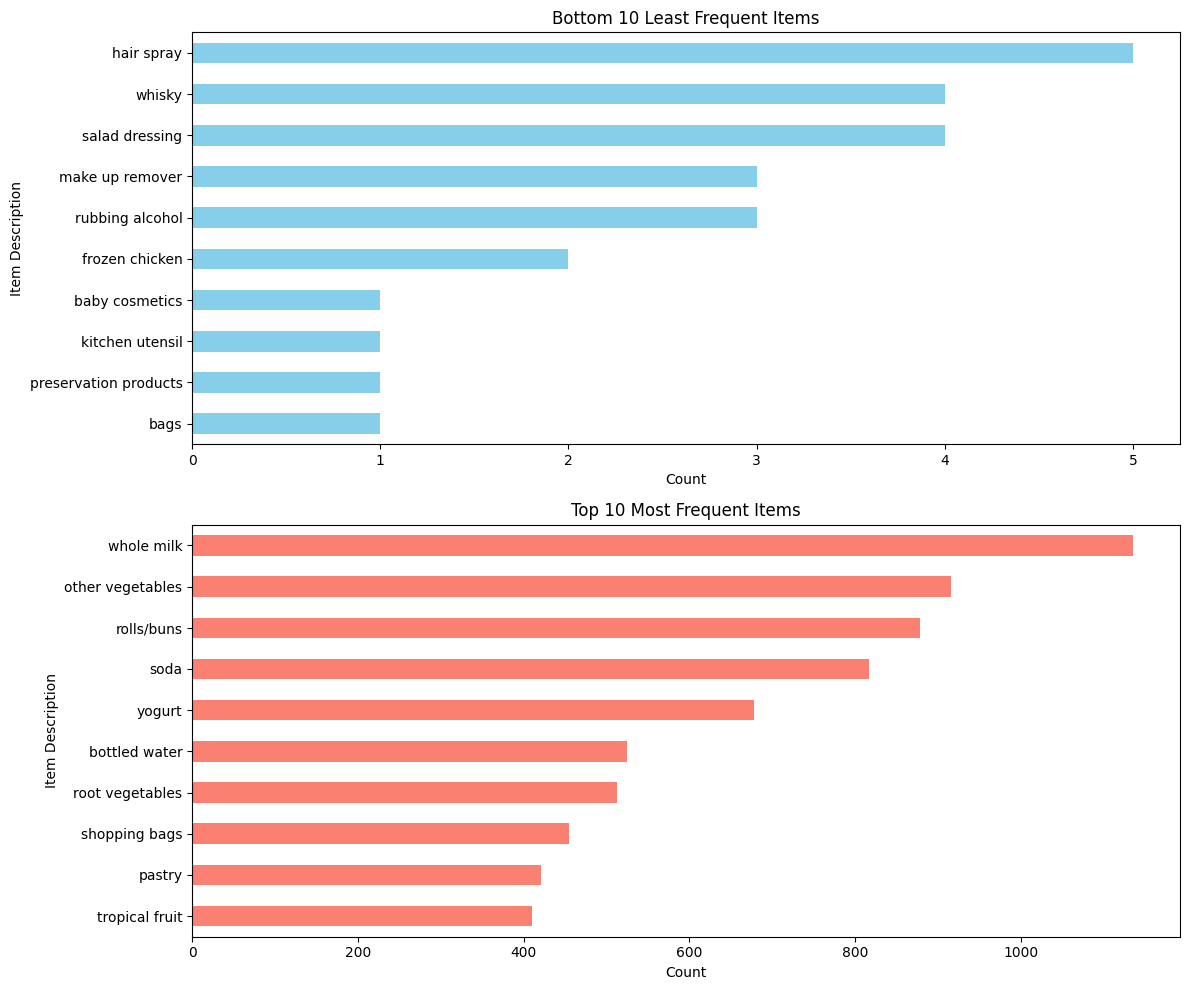

In [80]:


item_counts = train_df['itemDescription'].value_counts()
top_10_items = item_counts.head(10)
bottom_10_items = item_counts.tail(10).sort_values(ascending=True)  
plt.figure(figsize=(12, 10))


plt.subplot(2, 1, 1)
bottom_10_items.plot(kind='barh', color='skyblue')
plt.xlabel('Count')
plt.ylabel('Item Description')
plt.title('Bottom 10 Least Frequent Items')


plt.subplot(2, 1, 2)
top_10_items.sort_values().plot(kind='barh', color='salmon') 
plt.xlabel('Count')
plt.ylabel('Item Description')
plt.title('Top 10 Most Frequent Items')

plt.tight_layout()
plt.show()


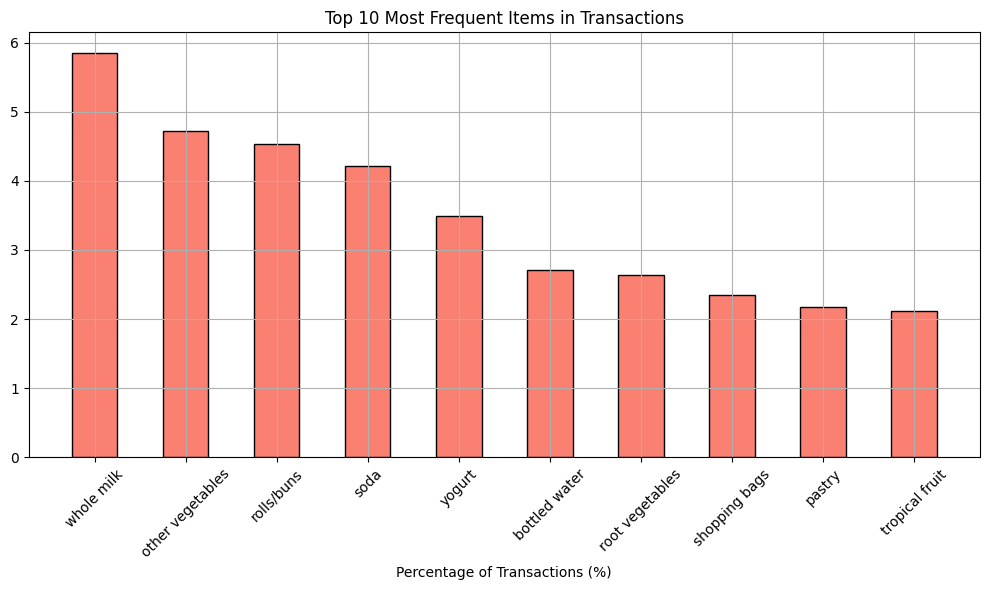

In [81]:
item_counts = train_df['itemDescription'].value_counts()
total_transactions = len(train_df)
item_percentage = (item_counts / total_transactions) * 100

top_n = 10
top_items = item_percentage.head(top_n)


plt.figure(figsize=(10, 6))
bars = plt.bar(top_items.index, top_items.values, edgecolor='black', color = 'salmon',width = 0.5 ) 
plt.xlabel("Percentage of Transactions (%)")
plt.title(f"Top {top_n} Most Frequent Items in Transactions")
#plt.gca().invert_yaxis()
plt.grid(True)
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [82]:
top_10_items

whole milk          1135
other vegetables     916
rolls/buns           878
soda                 816
yogurt               678
bottled water        525
root vegetables      512
shopping bags        455
pastry               421
tropical fruit       410
Name: itemDescription, dtype: int64

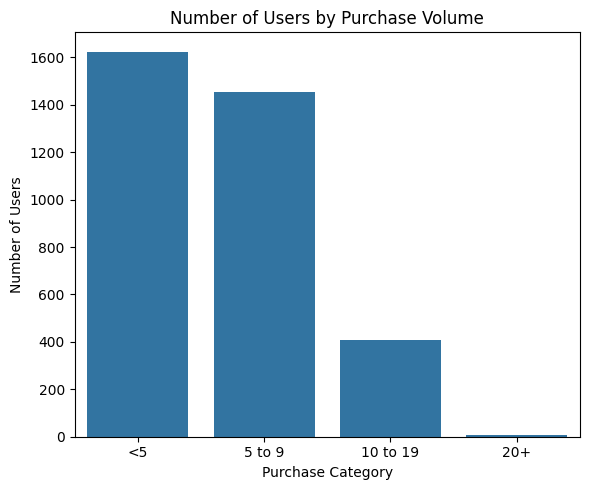

In [83]:

user_counts = train_df.groupby('User_id').size().reset_index(name='count')
def map_bins(data):
    if data < 5:
        return '<5'
    elif 5 <= data < 10:
        return '5 to 9'
    elif 10 <= data < 20:
        return '10 to 19'
    else:
        return '20+'

user_counts['purchase_category'] = user_counts['count'].apply(map_bins)

plt.figure(figsize=(6, 5))
sns.countplot(data=user_counts, x='purchase_category', order=['<5', '5 to 9', '10 to 19', '20+'])
plt.title('Number of Users by Purchase Volume')
plt.xlabel('Purchase Category')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()


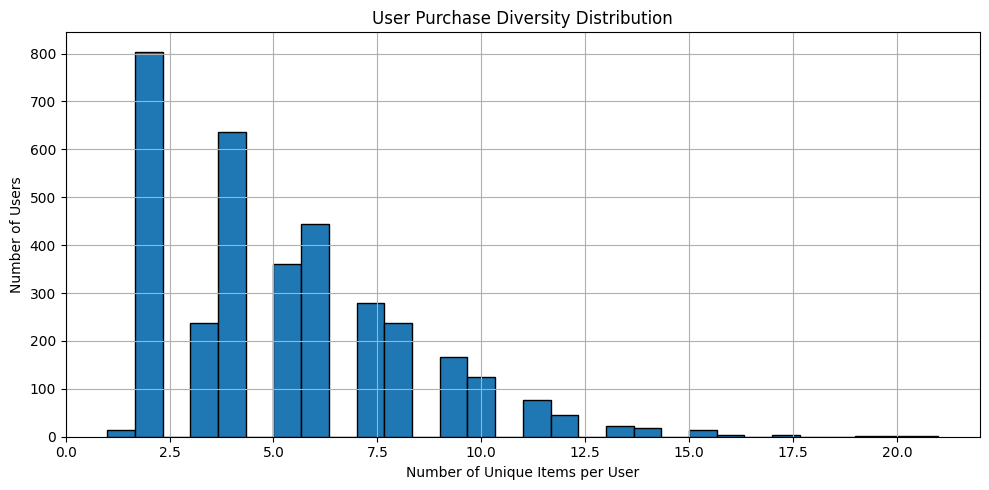

In [84]:
user_item_counts = train_df.groupby('User_id')['itemDescription'].nunique()

plt.figure(figsize=(10, 5))
plt.hist(user_item_counts, bins=30, edgecolor='black')
plt.xlabel("Number of Unique Items per User")
plt.ylabel("Number of Users")
plt.title("User Purchase Diversity Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

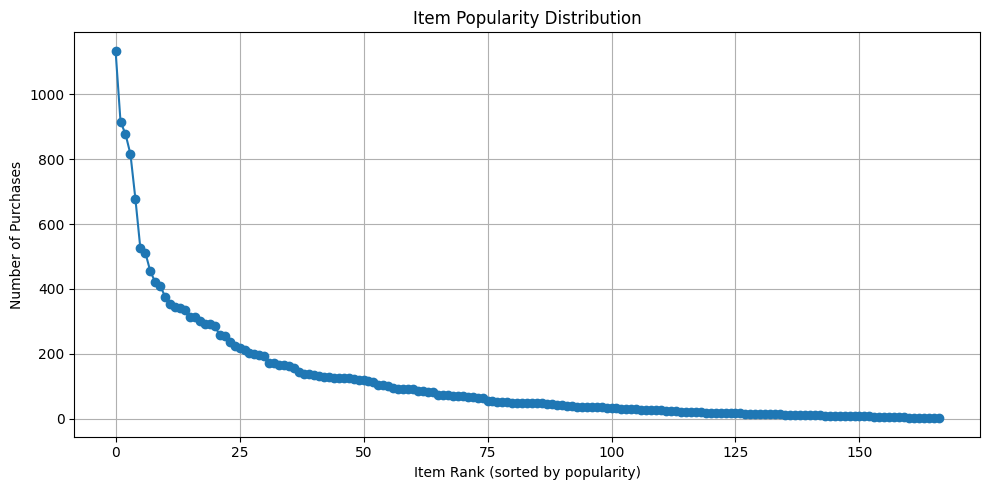

In [85]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(item_counts)), item_counts.values, marker='o')
plt.xlabel("Item Rank (sorted by popularity)")
plt.ylabel("Number of Purchases")
plt.title("Item Popularity Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

In [86]:
def gini(array):
    sorted_array = np.sort(array)
    n = len(array)
    cumulative_sum = np.cumsum(sorted_array)
    gini_index = (2 * np.sum((np.arange(1, n+1) * sorted_array)) / (n * np.sum(sorted_array))) - (n + 1) / n
    return gini_index

gini_score = gini(item_counts.values)
print(f"Gini Coefficient for Item Popularity: {gini_score:.4f}")

Gini Coefficient for Item Popularity: 0.6366


#### Key findings

1. The data set is suitable for collaborative filtering, since all unique users have interacted with the popular item
2. However, user-item matrix shows that the data is sparse ( 96.86%) meaning that only 3.33% have overlapping purhcase history. Hence, item based collaborative filtering would be better 


### 3. Model training and selection

In [87]:
train_df = train_df.sort_values('Date').reset_index(drop=True)
split_index = int(len(train_df) * 0.8)

train_sub_df = train_df.iloc[:split_index]
dev_sub = train_df.iloc[split_index:]


In [88]:
train_df,

(       User_id       Date           itemDescription  year  month  day  \
 0         2351  1/01/2014                   cleaner  2014      1    1   
 1         3681  1/01/2014        whipped/sour cream  2014      1    1   
 2         1440  1/01/2014                    yogurt  2014      1    1   
 3         2974  1/01/2014        whipped/sour cream  2014      1    1   
 4         2727  1/01/2014    frozen potato products  2014      1    1   
 ...        ...        ...                       ...   ...    ...  ...   
 19377     4098  9/12/2014                whole milk  2014     12    9   
 19378     3378  9/12/2014                    onions  2014     12    9   
 19379     4201  9/12/2014                     syrup  2014     12    9   
 19380     4418  9/12/2014  long life bakery product  2014     12    9   
 19381     1392  9/12/2014          other vegetables  2014     12    9   
 
        day_of_week  
 0                2  
 1                2  
 2                2  
 3                2  


#### 3.1 Item based collborative filtering

##### 3.1.1 Using bought and not bought scenario (0, 1) - jacquard similarity  

reference :practical recommender systems ch-7 section 7.2,153 - 156

In [89]:
item_user_matrix = train_sub_df.pivot_table(
    index='itemDescription', 
    columns='User_id', 
    aggfunc='size', 
    fill_value=0
)
item_user_matrix = (item_user_matrix > 0).astype(int)

In [90]:

knn_model = NearestNeighbors(metric='jaccard', algorithm='brute')
knn_model.fit(item_user_matrix.astype(bool))

item_index = item_user_matrix.index.get_loc('cleaner')


In [91]:
distances, indices = knn_model.kneighbors(
    [item_user_matrix.iloc[item_index].values],
    n_neighbors=6
)
similar_items = item_user_matrix.index[indices.flatten()[1:]]
similar_items

Index(['prosecco', 'bathroom cleaner', 'roll products ', 'sauces',
       'female sanitary products'],
      dtype='object', name='itemDescription')

In [92]:
#https://www.analyticsvidhya.com/blog/2021/05/item-based-collaborative-filtering-build-your-own-recommender-system/ - 4th april
# https://umair-iftikhar.medium.com/building-a-simple-recommendation-system-with-item-item-collaborative-filtering-in-python-3baae5179c52


def generate_recommendations(user_id, matrix, model, top_n=5):
    if user_id not in matrix.columns:
        return []

    past_items = matrix.index[matrix.loc[:, user_id] > 0].tolist()
    recommended_items = {}

    for item in past_items:
        item_vector = matrix.loc[item].values.reshape(1, -1)
        distances, indices = model.kneighbors(item_vector, n_neighbors=6)

        for i in range(1, len(indices.flatten())):  
            similar_item = matrix.index[indices.flatten()[i]]
            similarity_score = 1 - distances.flatten()[i]
            if similar_item in past_items:
                
                continue

            recommended_items[similar_item] = recommended_items.get(similar_item, 0) + similarity_score

    sorted_recs = sorted(recommended_items.items(), key=lambda x: x[1], reverse=True)
    return [item for item, score in sorted_recs[:top_n]]


generate_recommendations(user_id= 4418, matrix=item_user_matrix, model=knn_model, top_n = 5)


['sausage', 'decalcifier', 'yogurt', 'chocolate', 'curd cheese']

In [93]:
def evaluate_model(test_set, matrix, top_n, model):
    ground_truth = test_set.groupby('User_id')['itemDescription'].apply(set).to_dict()
    results = []
    for user_id in tqdm(ground_truth, desc="Evaluating users"):
        if user_id in matrix.columns:
            recommendations = generate_recommendations(user_id=user_id, matrix=matrix, model=model, top_n=top_n)
            actual = ground_truth[user_id]

            intersection = set(recommendations) & actual
            precision = len(intersection) / (top_n)
            recall = len(intersection) / len(actual) if len(actual) > 0 else 0

            results.append((precision, recall))
    precisions, recalls = zip(*results)
    avg_precision = sum(precisions) / len(precisions)
    avg_recall = sum(recalls) / len(recalls)

    print(f"Average Precision@{top_n-1}: {avg_precision:.4f}")
    print(f"Average Recall{top_n-1}: {avg_recall:.4f}")

evaluate_model(dev_sub, item_user_matrix, 6, model = knn_model)

Evaluating users:   0%|          | 0/1368 [00:00<?, ?it/s]

Evaluating users: 100%|██████████| 1368/1368 [00:07<00:00, 187.14it/s]

Average Precision@5: 0.0926
Average Recall5: 0.2053


##### 3.1.2 Using bought and not bought scenario frequency - cosine similarity  

In [94]:
item_user_matrix_2 = train_sub_df.pivot_table(
    index='itemDescription',
    columns='User_id',
    aggfunc='size',
    fill_value=0
)

knn_cosine = NearestNeighbors(metric='cosine', algorithm='brute')
knn_cosine.fit(item_user_matrix_2)

evaluate_model(dev_sub, item_user_matrix_2, 6,knn_cosine )

Evaluating users: 100%|██████████| 1368/1368 [00:20<00:00, 66.49it/s] 

Average Precision@5: 0.0938
Average Recall5: 0.2082


#### 3.1.3 Factoring recency with frequency of purchase

In [95]:

item_counts_by_date = train_sub_df.groupby(['Date', 'itemDescription']).size()

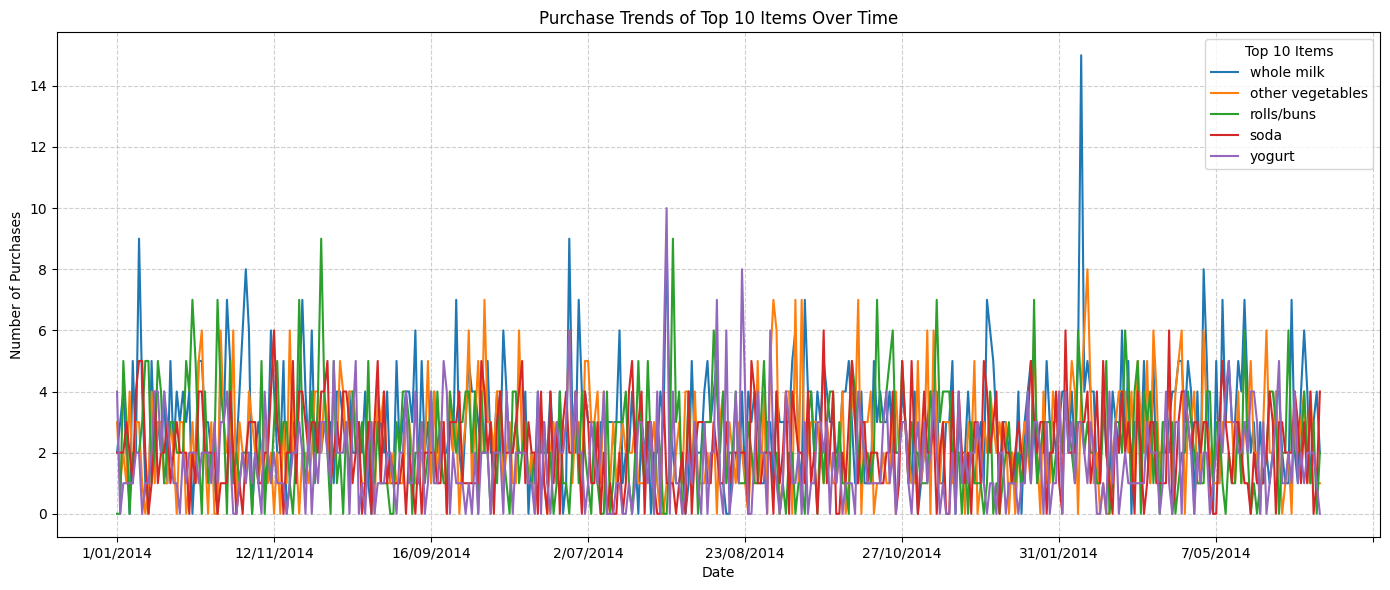

In [96]:
item_counts = train_df['itemDescription'].value_counts()
top_10_items = item_counts.head(5)
bottom_10_items = item_counts.tail(5).sort_values(ascending=True)  
t_10_items = top_10_items.reset_index()['index'].tolist()
b_10_items = bottom_10_items.reset_index()['index'].tolist()
item_counts_by_date = train_df.groupby(['Date', 'itemDescription']).size().unstack(fill_value=0)
item_counts_by_date[t_10_items].plot(figsize=(14, 6))
plt.title("Purchase Trends of Top 10 Items Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Purchases")
plt.legend(title="Top 10 Items")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [97]:
t_10_items[0]

'whole milk'

In [98]:
train_df

,User_id,Date,itemDescription,year,month,day,day_of_week
0,2351,1/01/2014,cleaner,2014,1,1,2
1,3681,1/01/2014,whipped/sour cream,2014,1,1,2
2,1440,1/01/2014,yogurt,2014,1,1,2
3,2974,1/01/2014,whipped/sour cream,2014,1,1,2
4,2727,1/01/2014,frozen potato products,2014,1,1,2
...,...,...,...,...,...,...,...
19377,4098,9/12/2014,whole milk,2014,12,9,1
19378,3378,9/12/2014,onions,2014,12,9,1
19379,4201,9/12/2014,syrup,2014,12,9,1
19380,4418,9/12/2014,long life bakery product,2014,12,9,1


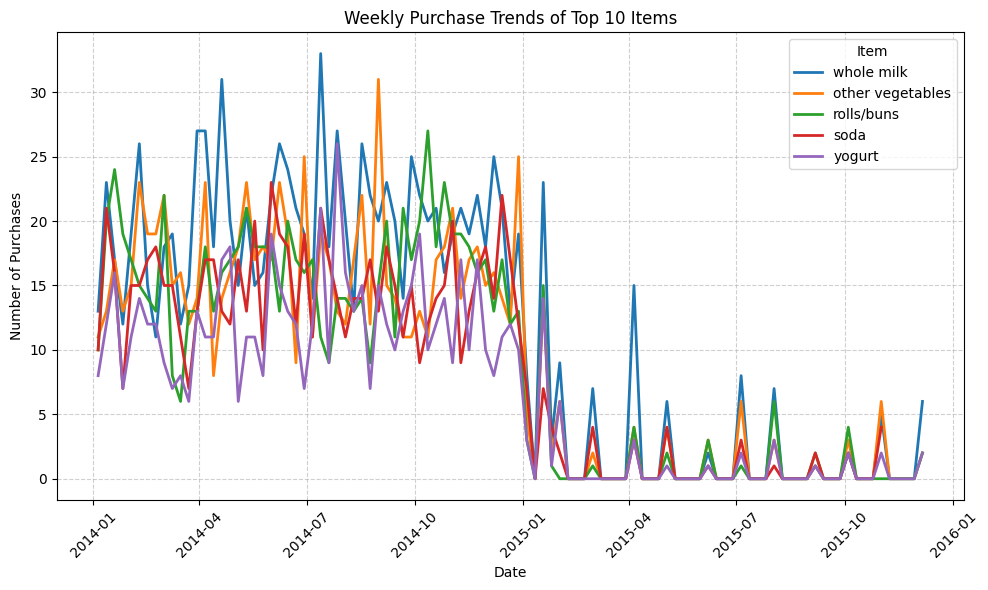

In [99]:
plt.figure(figsize=(10, 6))
for i in t_10_items:
    t = train_df[train_df['itemDescription'] == i]
    purchases = t.groupby('Date').agg({'User_id': 'count'})
    purchases.index = pd.to_datetime(purchases.index)
    purchases_weekly = purchases.resample('W').sum()

    plt.plot(purchases_weekly.index, purchases_weekly['User_id'], label=i, linewidth=2)

plt.title("Weekly Purchase Trends of Top 10 Items")
plt.xlabel("Date")
plt.ylabel("Number of Purchases")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Item")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [100]:
train_sub_df['Date'] = pd.to_datetime(train_sub_df['Date'])
max_date = train_sub_df['Date'].max()
train_sub_df['recency_weight'] = 1 / (1 + (max_date - train_sub_df['Date']).dt.days)

In [101]:
train_sub_df

,User_id,Date,itemDescription,year,month,day,day_of_week,recency_weight
0,2351,2014-01-01,cleaner,2014,1,1,2,0.001429
1,3681,2014-01-01,whipped/sour cream,2014,1,1,2,0.001429
2,1440,2014-01-01,yogurt,2014,1,1,2,0.001429
3,2974,2014-01-01,whipped/sour cream,2014,1,1,2,0.001429
4,2727,2014-01-01,frozen potato products,2014,1,1,2,0.001429
...,...,...,...,...,...,...,...,...
15500,2058,2014-04-02,rolls/buns,2014,2,4,1,0.001642
15501,4312,2014-04-02,whole milk,2014,2,4,1,0.001642
15502,3556,2014-04-02,pork,2014,2,4,1,0.001642
15503,1706,2014-04-02,soda,2014,2,4,1,0.001642


In [102]:
temp_train_sub = (
    train_sub_df
    .groupby(['Date', 'User_id', 'itemDescription'])
    .size()
    .reset_index(name='frequency_purchase')
)


In [103]:
freq_item   = train_sub_df.groupby(['itemDescription']).size()


temp_train_sub['frequency_weight'] = temp_train_sub['itemDescription'].map(freq_item)
temp_train_sub['recency_score'] = 1 / (1 + (max_date - temp_train_sub['Date']).dt.days)

In [104]:
temp_train_sub['weighted_score'] = temp_train_sub['recency_score'] * temp_train_sub['frequency_weight']

min_val = temp_train_sub['weighted_score'].min()
max_val = temp_train_sub['weighted_score'].max()

temp_train_sub['weighted_score_normalized'] = np.log1p(temp_train_sub['weighted_score'])

In [105]:
temp_train_sub = temp_train_sub[['User_id', 'itemDescription', 'weighted_score_normalized']]

item_user_matrix_weighted = temp_train_sub.pivot_table(
    index='itemDescription',
    columns='User_id',
    values='weighted_score_normalized',
    aggfunc='sum',
    fill_value=0
)

In [106]:
item_user_matrix_weighted

User_id,1000,1001,1002,1003,1004,1005,1009,1010,1011,1012,...,4987,4988,4990,4991,4992,4993,4995,4997,4999,5000
itemDescription,,,,,,,,,,,,,,,,,,,,,
Instant food products,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
UHT-milk,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.189621,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
abrasive cleaner,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.022942,0.0,0.000000,0.0,0.0
artif. sweetener,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
baby cosmetics,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
white bread,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
white wine,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
whole milk,0.998729,2.123232,0.932904,0.0,3.082392,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,1.084045,0.0,0.000000,0.0,0.831158,0.0,0.0


In [107]:
knn_cosine = NearestNeighbors(metric='cosine', algorithm='brute')
knn_cosine.fit(item_user_matrix_weighted)

evaluate_model(dev_sub, item_user_matrix_weighted, 6,knn_cosine )

Evaluating users:   0%|          | 0/1368 [00:00<?, ?it/s]

Evaluating users: 100%|██████████| 1368/1368 [00:14<00:00, 94.99it/s] 

Average Precision@5: 0.0621
Average Recall5: 0.1376


#### 3.1.4 factoring recency only

In [108]:
item_user_matrix_recency = train_sub_df.pivot_table(
    index='itemDescription', 
    columns='User_id', 
    values='recency_weight',
    aggfunc='sum',
    fill_value=0
)

knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(item_user_matrix_recency)
evaluate_model(dev_sub, item_user_matrix_recency, 6,knn_model )

Evaluating users: 100%|██████████| 1368/1368 [00:20<00:00, 67.28it/s] 

Average Precision@5: 0.0337
Average Recall5: 0.0713


### 3.2 User based collborative filtering

In [109]:

user_item_matrix = train_sub_df.pivot_table(
    index='User_id', 
    columns='itemDescription', 
    aggfunc='size', 
    fill_value=0
)

user_item_matrix = (user_item_matrix > 0).astype(int)


knn_user_model = NearestNeighbors(metric='jaccard', algorithm='brute')
knn_user_model.fit(user_item_matrix.astype(bool))


NearestNeighbors(algorithm='brute', metric='jaccard')

In [110]:
from collections import defaultdict

def generate_user_based_recommendations(user_id, matrix, model, top_n=5):
    if user_id not in matrix.index:
        return []

    user_vector = matrix.loc[user_id].values.reshape(1, -1)
    distances, indices = model.kneighbors(user_vector, n_neighbors=6)  # 1 target + 5 neighbors

    recommended_items = defaultdict(float)
    user_items = set(matrix.columns[matrix.loc[user_id] > 0])

    for neighbor_idx, dist in zip(indices.flatten()[1:], distances.flatten()[1:]):
        neighbor_id = matrix.index[neighbor_idx]
        similarity = 1 - dist
        neighbor_items = matrix.columns[matrix.loc[neighbor_id] > 0]

        for item in neighbor_items:
            if item not in user_items:
                recommended_items[item] += similarity  # weighted by similarity

    # Sort and return top N
    sorted_recs = sorted(recommended_items.items(), key=lambda x: x[1], reverse=True)
    return [item for item, score in sorted_recs[:top_n]]


In [111]:
from tqdm import tqdm

def evaluate_user_cf_model(test_set, matrix, model, top_n=5):
    ground_truth = test_set.groupby('User_id')['itemDescription'].apply(set).to_dict()
    results = []

    for user_id in tqdm(ground_truth, desc="Evaluating users"):
        if user_id in matrix.index:
            recommendations = generate_user_based_recommendations(user_id, matrix, model, top_n)
            actual = ground_truth[user_id]

            intersection = set(recommendations) & actual
            precision = len(intersection) / top_n
            recall = len(intersection) / len(actual) if len(actual) > 0 else 0

            results.append((precision, recall))

    if not results:
        print("No overlapping users found.")
        return

    precisions, recalls = zip(*results)
    avg_precision = sum(precisions) / len(precisions)
    avg_recall = sum(recalls) / len(recalls)

    print(f"Average Precision@{top_n}: {avg_precision:.4f}")
    print(f"Average Recall@{top_n}: {avg_recall:.4f}")


In [112]:
evaluate_user_cf_model(dev_sub, user_item_matrix, knn_user_model, top_n=5)

Evaluating users:   0%|          | 0/1368 [00:00<?, ?it/s]

Evaluating users: 100%|██████████| 1368/1368 [00:01<00:00, 716.37it/s]

Average Precision@5: 0.0366
Average Recall@5: 0.0654


### Combining frequent items with CF experiment

#### Best Model - Using bought and not bought scenario frequency - cosine similarity  

### Final

In [113]:
# CF - Model


def build_cf_model(data):
    item_user_matrix = data.pivot_table(
        index='itemDescription',
        columns='User_id',
        aggfunc='size',
        fill_value=0
    )
    knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
    knn_model.fit(item_user_matrix)
    return item_user_matrix, knn_model



def generate_cf_recommendation(user_id, matrix, model, top_n=10):
    return generate_recommendations(user_id=user_id, matrix=matrix, model=model, top_n=top_n)

In [114]:
# frequent items  code from Task 1

def generate_top_items(df):
    import pandas as pd
    import numpy as np
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import fpgrowth,association_rules

    # I load the data
    
    # I clean and preprocess the data
    df = df.dropna(subset=['User_id', 'itemDescription']).copy()
    df['User_id'] = df['User_id'].astype(int)
    df['itemDescription'] = df['itemDescription'].astype(str)
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    df['Transaction_ID'] = df['User_id'].astype(str) + '_' + df['Date'].astype(str)
    df_sorted = df.sort_values("Date")
    split_index = int(0.7 * len(df_sorted))
    train_data = df_sorted.iloc[:split_index].copy()

    # I apply recency scoring
    train_data = train_data.sort_values(by=['User_id', 'Date'], ascending=[True, False])
    train_data['RecencyRank'] = train_data.groupby('User_id')['Date'].rank(method='dense', ascending=False)
    train_data['RecencyWeight'] = 1 / train_data['RecencyRank']
    recency_scores = train_data.groupby('itemDescription')['RecencyWeight'].sum().to_dict()

    # I prepare baskets and encode
    baskets = train_data.groupby("Transaction_ID")["itemDescription"].apply(list).tolist()
    encoder = TransactionEncoder()
    encoded_baskets = encoder.fit_transform(baskets)
    encoded_df = pd.DataFrame(encoded_baskets, columns=encoder.columns_)

    # I mine frequent patterns
    frequent_itemsets = fpgrowth(encoded_df, min_support=0.005, use_colnames=True)
    frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
    frequent_itemsets = frequent_itemsets[frequent_itemsets['length'] > 1].copy()

    # I calculate recency-based scores
    frequent_itemsets['recency_score'] = frequent_itemsets['itemsets'].apply(
        lambda items: sum([recency_scores.get(item, 0) for item in items])
    )

   
    # I select top 5 itemsets by score
    top_itemsets = frequent_itemsets.sort_values(by='recency_score', ascending=False).head(5)['itemsets'].tolist()

    # I flatten all unique items from top itemsets into a single list
    unique_items = sorted(set(item for itemset in top_itemsets for item in itemset))

    

    return unique_items


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

item_user_matrix, knn_model = build_cf_model(train_df)


def task_2_output(data, user_id, n_recommendations=5, flag = 'with'):
    additional_recs = set()
    user_history = set(data[data['User_id'] == user_id]['itemDescription'].unique())
    item_user_matrix, knn_model = build_cf_model(train_df)
    cf_recs = generate_cf_recommendation(user_id=user_id, matrix=item_user_matrix, model=knn_model, top_n=n_recommendations)

    if flag == 'without':
        return cf_recs[:n_recommendations]
    
    else:
        items = generate_top_items(data)
        pattern_set = set(items)
        pattern_clean = pattern_set - user_history
        cf_set = set(cf_recs)
        boosted = list(cf_set & pattern_clean)
        rest = list((cf_set | pattern_clean) - set(boosted))
        final = boosted + rest
        return final[:n_recommendations]
        # print(f" CF set {cf_set}")
        # for _, row in rules.iterrows():
        #     #if row['antecedents'].issubset(cf_set):
        #     #if row['antecedents'].issubset(user_history):
        #     if row['antecedents'] & user_history:
        #         additional_recs.update(row['consequents'])
        # print(f"Additional recs : {additional_recs}")
        # print(f"User history :{user_history}")
        # additional_recs = list(additional_recs - cf_set-user_history)
        # final_recs = cf_recs + additional_recs
        # return final_recs[:n_recommendations]


n_recommendation = 5
# rules = generate_apriori_rules(train_df)

print(task_2_output(data = train_df,
              user_id = 1000,
              n_recommendations=n_recommendation))

print(task_2_output(data = train_df,
              user_id = 1000, 
              n_recommendations=n_recommendation,flag = 'without'))

['soda', 'other vegetables', 'rolls/buns', 'yogurt', 'shopping bags']
['rolls/buns', 'soda', 'other vegetables', 'shopping bags', 'yogurt']


In [116]:
import numpy as np
from sklearn.metrics import ndcg_score, dcg_score

def precision_recall_hit_ndcg(predicted, actual, k=5, all_items=None):
    predicted_top_k = predicted[:k]
    actual_set = set(actual)

    hits = [item in actual_set for item in predicted_top_k]
    precision = sum(hits) / k
    recall = sum(hits) / len(actual_set) if actual_set else 0
    hit_rate = int(any(hits))

    if all_items is None:
        all_items = list(set(predicted + actual))

    item_index = {item: idx for idx, item in enumerate(all_items)}
    y_true = np.zeros((1, len(all_items)))
    y_score = np.zeros((1, len(all_items)))

    for item in actual:
        y_true[0, item_index[item]] = 1
    for rank, item in enumerate(predicted_top_k):
        y_score[0, item_index[item]] = 1 / (rank + 1)

    ndcg = ndcg_score(y_true, y_score, k=k)
    return precision, recall, hit_rate, ndcg

def avg(metric_list, idx):
    return round(np.mean([m[idx] for m in metric_list]), 4)


from tqdm import tqdm
import numpy as np

def evaluate_cf_vs_hybrid(train_df, test_df, k=5):

    diff_count = 0
    item_user_matrix, knn_model = build_cf_model(train_df)
    users = test_df['User_id'].unique()
    all_items = train_df['itemDescription'].unique().tolist()
    pattern_items = generate_top_items(train_df)
    pattern_set = set(pattern_items)

    metrics_cf = []
    metrics_hybrid = []

    for user_id in tqdm(users, desc="Evaluating users"):
        actual = test_df[test_df['User_id'] == user_id]['itemDescription'].unique()
        if len(actual) == 0:
            continue

     
        cf_recs = generate_cf_recommendation(user_id=user_id, matrix=item_user_matrix, model=knn_model, top_n=k)

       
        user_history = set(train_df[train_df['User_id'] == user_id]['itemDescription'].unique())

 
        cf_set = set(cf_recs)
        pattern_clean = pattern_set - user_history
        boosted = list(cf_set & pattern_clean)
        rest = list((cf_set | pattern_clean) - set(boosted))
        hybrid_recs = (boosted + rest)[:k]


        metrics_cf.append(precision_recall_hit_ndcg(cf_recs, actual, k, all_items))
        metrics_hybrid.append(precision_recall_hit_ndcg(hybrid_recs, actual, k,all_items))

        if cf_recs != hybrid_recs:
            diff_count += 1

    

    return {
        'CF': {
            'Precision@k': avg(metrics_cf, 0),
            'Recall@k': avg(metrics_cf, 1),
            'HitRate@k': avg(metrics_cf, 2),
            'NDCG@k': avg(metrics_cf, 3)
        },
        'Hybrid': {
            'Precision@k': avg(metrics_hybrid, 0),
            'Recall@k': avg(metrics_hybrid, 1),
            'HitRate@k': avg(metrics_hybrid, 2),
            'NDCG@k': avg(metrics_hybrid, 3)
        }
    }, diff_count

 


results, diff_count = evaluate_cf_vs_hybrid(train_sub_df, dev_sub, k=5)

print("CF vs Hybrid Evaluation (Top-5):")
for model, metrics in results.items():
    print(f"\n{model}")
    for metric, score in metrics.items():
        print(f"{metric}: {score}")

Evaluating users: 100%|██████████| 1368/1368 [00:19<00:00, 69.81it/s] 

CF vs Hybrid Evaluation (Top-5):

CF
Precision@k: 0.0848
Recall@k: 0.1558
HitRate@k: 0.3545
NDCG@k: 0.1387

Hybrid
Precision@k: 0.112
Recall@k: 0.2069
HitRate@k: 0.4656
NDCG@k: 0.1665
